IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [ ]:
# Descarga de datos desde Kaggle

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [51]:
# Definimos una ruta temporal
def ruta_archivo(archivo):
    return os.path.join("Board Games", archivo)

# Creamos el DataFrame general.
df_general = pd.read_csv(ruta_archivo("bgg_GameItem.csv"))

# Podemos ver que dicho DataFrame presenta algunas columnas que están codificadas por ID. -> Datos anidados
# Sabemos que esos ID´s se pueden relacionar directamente con los demás DataSets, por lo que creamos un DataFrame por cada csv.

# Artistas y Diseñadores
df_person = pd.read_csv(ruta_archivo("bgg_Person.csv"))

# Mecánicas de juego
df_mechanic = pd.read_csv(ruta_archivo("bgg_Mechanic.csv"))

# Categoría de juego
df_category = pd.read_csv(ruta_archivo("bgg_Category.csv"))

# Tipo de juego
df_game_type = pd.read_csv(ruta_archivo("bgg_GameType.csv"))

# Familia de juegos
df_family = pd.read_csv(ruta_archivo("bgg_GameFamily.csv"))

# Editorial
df_publisher = pd.read_csv(ruta_archivo("bgg_Publisher.csv"))


# Se puede intuir que es necesario desarrollar una función capaz de relacionar los ID´s con su respectivo valor en cada DataFrame.
# La idea será crear un nuevo DataFrame con dicha información (no anidada).

# Para el desarrollo de esta función, haremos uso del siguiente promp: 

# Cuento con un DataFrame cuyas columnas presentan ID´s anidadas, siguiendo la relación de a continuación:

# df_general["deigner"] -> df_person
# df_general["artist"] -> df_person
# df_general["mechanic"] -> df_mechanic
# df_general["category"] -> df_category
# df_general["game_type"] -> df_game_type
# df_general["family"] -> df_family
# df_general["publisher"] -> df_publisher

# Quiero que desarrolles un algoritmo capaz de relacionar cada ID del DataFrame original con su respectivo valor en el DataFrame correspondiente
# siguiendo la relación columna_df_general -> dt_columna.

# Finalmente, genera un nuevo DataFrame con nombre "df_final" en el que condenses toda la información del DataSet en un único archivo .csv.

# Respuesta generada por Deepseek:

#1. Crear mapeos
map_person = df_person.set_index('bgg_id')['name'].to_dict()
map_mechanic = df_mechanic.set_index('bgg_id')['name'].to_dict()
map_category = df_category.set_index('bgg_id')['name'].to_dict()
map_game_type = df_game_type.set_index('bgg_id')['name'].to_dict()
map_family = df_family.set_index('bgg_id')['name'].to_dict()
map_publisher = df_publisher.set_index('bgg_id')['name'].to_dict()

#2. Función de mapeo
def map_multi_id(ids_string, mapping_dict):
    if pd.isna(ids_string) or ids_string == '': return []
    try:
        ids_list = str(ids_string).split(',')
        return [mapping_dict.get(int(id_str.strip()), f"ID_{id_str}") for id_str in ids_list if id_str.strip()]
    except (ValueError, AttributeError):
        return [f"Error: {ids_string}"]

#3. DataFrame mapeado
df_mapeado = pd.DataFrame(index=df_general.index)
columnas_base = ['bgg_id', 'name', 'year', 'min_players', 'max_players', 'min_play_time', 'max_play_time', 'min_age', 'avg_rating']
for col in columnas_base:
    if col in df_general.columns: df_mapeado[col] = df_general[col]

#4. Aplicar mapeos
df_mapeado["game_type_name"] = df_general["game_type"].apply(lambda x: "; ".join(map_multi_id(x, map_game_type)) if pd.notna(x) else "")
df_mapeado["designer_str"] = df_general["designer"].apply(lambda x: "; ".join(map_multi_id(x, map_person)) if pd.notna(x) else "")
df_mapeado["artist_str"] = df_general["artist"].apply(lambda x: "; ".join(map_multi_id(x, map_person)) if pd.notna(x) else "")
df_mapeado["publisher_str"] = df_general["publisher"].apply(lambda x: "; ".join(map_multi_id(x, map_publisher)) if pd.notna(x) else "")
df_mapeado["categories_str"] = df_general["category"].apply(lambda x: "; ".join(map_multi_id(x, map_category)) if pd.notna(x) else "")
df_mapeado["mechanics_str"] = df_general["mechanic"].apply(lambda x: "; ".join(map_multi_id(x, map_mechanic)) if pd.notna(x) else "")
df_mapeado["family_str"] = df_general["family"].apply(lambda x: "; ".join(map_multi_id(x, map_family)) if pd.notna(x) else "")

#5. DataFrame final ordenado
orden_columnas = [c for c in [
    "bgg_id", "name", "year", "min_players", "max_players", 
    "min_play_time", "max_play_time", "min_age", "avg_rating",
    "game_type_name", "designer_str", "artist_str", "publisher_str",
    "categories_str", "mechanics_str", "family_str"
] if c in df_mapeado.columns]

df_final = df_mapeado[orden_columnas]

#6. Guardar el DataFrame final en un archivo CSV
df_final.to_csv(ruta_archivo("bgg_GameItem_Final.csv"), index=False)

df_final.head(5)

,bgg_id,name,year,min_players,max_players,min_age,avg_rating,game_type_name,designer_str,artist_str,publisher_str,categories_str,mechanics_str,family_str
0,1,Die Macher,1986.0,3.0,5.0,14.0,7.60139,Strategy Game,Karl-Heinz Schmiel,Marcus Gschwendtner; ...,Hans im Glück; Moskit...,Economic; Negotiation...,Alliances; Area Major...,Country: Germany; Pol...
1,2,Dragonmaster,1981.0,3.0,4.0,12.0,6.65823,Strategy Game,"G. W. ""Jerry"" D'Arcey",Bob Pepper,E.S. Lowe; Milton Bra...,Card Game; Fantasy,Trick-taking,Components: Gems/Crys...
2,3,Samurai,1998.0,2.0,4.0,10.0,7.45913,Strategy Game,Reiner Knizia,Franz Vohwinkel,Fantasy Flight Games;...,Abstract Strategy; Me...,Area Majority / Influ...,Components: Map (Cont...
3,4,Tal der Könige,1992.0,2.0,4.0,12.0,6.62296,Strategy Game,Christian Beierer,Thomas di Paolo,KOSMOS,Ancient,Action Points; Area M...,Containers: Triangula...
4,5,Acquire,1964.0,2.0,6.0,12.0,7.33439,Strategy Game,Sid Sackson,Scott Okumura; Peter ...,3M; The Avalon Hill G...,Economic; Territory B...,Hand Management; Inve...,Components: 9 x 12 Gr...


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



In [52]:
tamaño = os.path.getsize("Board Games/bgg_GameItem_Final.csv")
print(f"Tamaño DataFrame: {tamaño/1024/1024:.2f} MB")

Tamaño DataFrame: 23.09 MB


In [53]:
t_category = os.path.getsize("Board Games/bgg_Category.csv")
t_family = os.path.getsize("Board Games/bgg_GameFamily.csv")
t_item = os.path.getsize("Board Games/bgg_GameItem.csv")
t_type = os.path.getsize("Board Games/bgg_GameType.csv")
t_mechanic = os.path.getsize("Board Games/bgg_Mechanic.csv")
t_person = os.path.getsize("Board Games/bgg_Person.csv")
t_publisher = os.path.getsize("Board Games/bgg_Publisher.csv")

t_final = t_category + t_family + t_item + t_type + t_mechanic + t_person + t_publisher
print(f"Tamaño CSV separados: {t_final/1024/1024:.2f} MB")

Tamaño CSV separados: 17.18 MB


La diferencia de peso se debe principalmente a que los CSV almacenan datos más simples, como números o strings, mientras que los archivos pandas almacenan datos de tipo objeto, los cuales son más complejos, y por tanto, más pesados.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


In [71]:
# Creamos una copia para no afectar el DataFrame original.
df_final = df_final.copy()

# Convertimos los datos de la columna "year" a valores numéricos.
df_final["year"] = pd.to_numeric(df_final["year"], errors="coerce")

# Obtenemos el rango de años.
print(f"Rango de años: {df_final['year'].min()} - {df_final['year'].max()}")

# Como el rango es válido, filtramos a partir de dicho rango.
df_final = df_final.query("1400 <= year <= 2025")

Rango de años: 1980.0 - 2025.0


El rango de años sí tiene sentido, pues sabemos de la existencia de juegos de mesa mucho más antiguos. Un ejemplo es el ajedrez, que data desde el año 600 d.C. aproximadamente.

El motivo por el cual haya un juego que date del 1400, y no desde antes, se puede deber a que se esté considerando el año en que se patentó, y no así el año en que se creó.

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

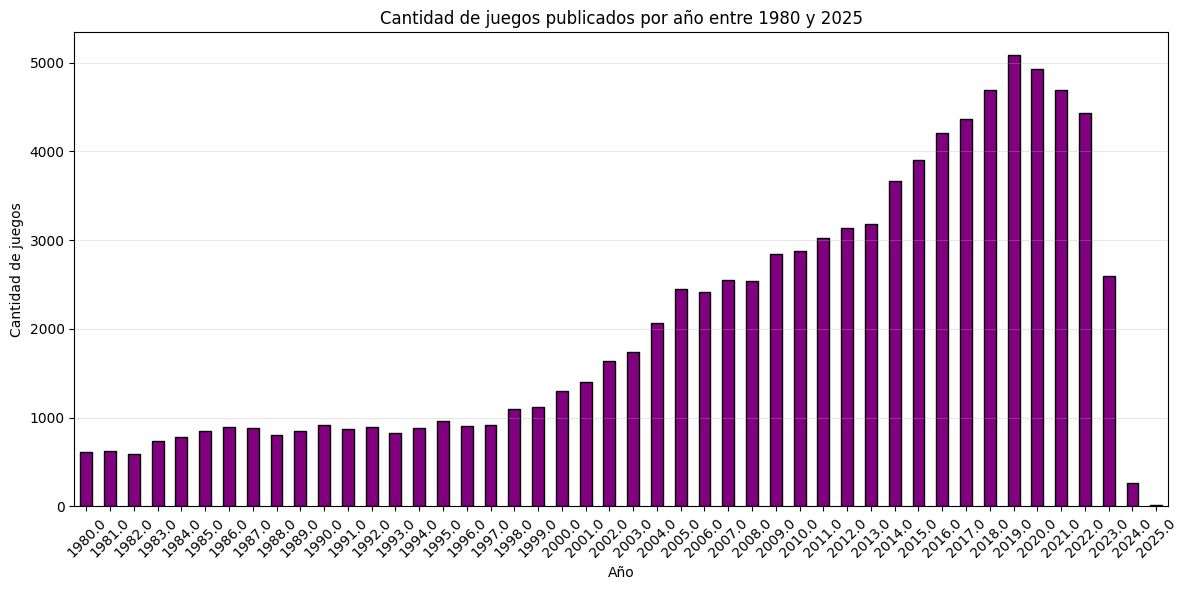

Año con más juegos: 2019.0 (5087 juegos)
Año con menos juegos: 2025.0 (16 juegos)


In [72]:
# Filtramos los juegos entre 1980 y 2025.
df_1980_2025 = df_final.query("1980 <= year <= 2025").copy()

# Contamos los juegos que se estrenaron cada año.
juegos_por_año = df_1980_2025['year'].value_counts().sort_index()

# Graficamos.
plt.figure(figsize=(12, 6))
juegos_por_año.plot(kind='bar', color='purple', edgecolor='black', alpha=1)
plt.title('Cantidad de juegos publicados por año entre 1980 y 2025')
plt.xlabel('Año')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determinamos el año con mayor y menor cantidad de juegos publicados.
print(f"Año con más juegos: {juegos_por_año.idxmax()} ({juegos_por_año.max()} juegos)")
print(f"Año con menos juegos: {juegos_por_año.idxmin()} ({juegos_por_año.min()} juegos)")

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

El principal problema que encontré en los datos fue el hecho de que el CSV principal (bgg_GameType.csv) presentaba columnas con datos anidados, lo que no permitía la manipulación directa de estos sin antes procesarlos y vincularlos correctamente con los demás DataFrames. Fue necesario la utilización de una función auxiliar capaz de mapear cada ID del DataFrame principal con su respectivo valor en los demás archivos CSV.